# Week 1 – Polynomial and Interaction Terms

## Objective

This notebook applies Week 1 linear regression concepts to the NBA game total prediction project.

The analysis includes:
- Baseline linear regression
- Polynomial terms
- Interaction terms
- Continuous and categorical predictors
- Multicollinearity analysis
- Variance Inflation Factor (VIF)

The target variable is `actual_total`, representing the total points scored in an NBA game.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor

from src.load_data import load_games, load_betting


In [2]:
games = load_games()
betting = load_betting()

print(games.columns)
print(betting.columns)

Index(['gameId', 'gameDateTimeEst', 'hometeamCity', 'hometeamName',
       'hometeamId', 'awayteamCity', 'awayteamName', 'awayteamId', 'homeScore',
       'awayScore', 'winner', 'gameType', 'gameSubtype', 'gameLabel',
       'gameSubLabel', 'seriesGameNumber', 'attendance', 'arenaId',
       'arenaName', 'arenaCity', 'arenaState', 'officials', 'gameDate'],
      dtype='object')
Index(['season', 'date', 'regular', 'playoffs', 'away', 'home', 'score_away',
       'score_home', 'q1_away', 'q2_away', 'q3_away', 'q4_away', 'ot_away',
       'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home', 'whos_favored',
       'spread', 'total', 'moneyline_away', 'moneyline_home', 'h2_spread',
       'h2_total', 'id_spread', 'id_total'],
      dtype='object')


/Users/josuelegarda/Desktop/nba_data_analysis/src/load_data.py:14: DtypeWarning: Columns (12,14,15,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


In [3]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73278 entries, 0 to 73277
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gameId            73278 non-null  int64  
 1   gameDateTimeEst   73278 non-null  object 
 2   hometeamCity      73271 non-null  object 
 3   hometeamName      73278 non-null  object 
 4   hometeamId        73278 non-null  int64  
 5   awayteamCity      73271 non-null  object 
 6   awayteamName      73278 non-null  object 
 7   awayteamId        73278 non-null  int64  
 8   homeScore         73278 non-null  int64  
 9   awayScore         73278 non-null  int64  
 10  winner            73278 non-null  int64  
 11  gameType          73278 non-null  object 
 12  gameSubtype       74 non-null     object 
 13  gameLabel         4042 non-null   object 
 14  gameSubLabel      327 non-null    object 
 15  seriesGameNumber  5822 non-null   object 
 16  attendance        1391 non-null   float6

In [4]:
betting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23118 entries, 0 to 23117
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          23118 non-null  int64  
 1   date            23118 non-null  object 
 2   regular         23118 non-null  bool   
 3   playoffs        23118 non-null  bool   
 4   away            23118 non-null  object 
 5   home            23118 non-null  object 
 6   score_away      23118 non-null  int64  
 7   score_home      23118 non-null  int64  
 8   q1_away         23118 non-null  int64  
 9   q2_away         23118 non-null  int64  
 10  q3_away         23118 non-null  int64  
 11  q4_away         23118 non-null  int64  
 12  ot_away         23118 non-null  int64  
 13  q1_home         23118 non-null  int64  
 14  q2_home         23118 non-null  int64  
 15  q3_home         23118 non-null  int64  
 16  q4_home         23118 non-null  int64  
 17  ot_home         23118 non-null 

In [5]:
games.head()

,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,...,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials,gameDate
0,42500404,2026-06-10 20:30:00,New York,Knicks,1610612752,San Antonio,Spurs,1610612759,107,106,...,NBA Finals,Game 4,Game 4,19812.0,30,Madison Square Garden,New York,NY,"Courtney Kirkland, Zach Zarba, James Williams,...",2026-06-10 20:30:00
1,42500403,2026-06-08 20:30:00,New York,Knicks,1610612752,San Antonio,Spurs,1610612759,111,115,...,NBA Finals,Game 3,Game 3,19812.0,30,Madison Square Garden,New York,NY,"Marc Davis, John Goble, Curtis Blair, Nick Buc...",2026-06-08 20:30:00
2,42500402,2026-06-05 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,104,105,...,NBA Finals,Game 2,Game 2,19014.0,1000118,Frost Bank Center,San Antonio,TX,"Tony Brothers, Josh Tiven, Mitchell Ervin, Tyl...",2026-06-05 20:30:00
3,42500401,2026-06-03 20:30:00,San Antonio,Spurs,1610612759,New York,Knicks,1610612752,95,105,...,NBA Finals,Game 1,Game 1,18835.0,1000118,Frost Bank Center,San Antonio,TX,"James Capers, JB DeRosa, Scott Foster, Sean Wr...",2026-06-03 20:30:00
4,42500317,2026-05-30 20:00:00,Oklahoma City,Thunder,1610612760,San Antonio,Spurs,1610612759,103,111,...,West Conf. Finals,Game 7,Game 7,18203.0,1000052,Paycom Center,Oklahoma City,OK,"Marc Davis, John Goble, Josh Tiven, Mitchell E...",2026-05-30 20:00:00


In [6]:
betting.head()

,season,date,regular,playoffs,away,home,score_away,score_home,q1_away,q2_away,...,ot_home,whos_favored,spread,total,moneyline_away,moneyline_home,h2_spread,h2_total,id_spread,id_total
0,2008,2007-10-30,True,False,por,sa,97,106,26,23,...,0,home,13.0,189.5,900.0,-1400.0,5.0,95.0,0.0,1
1,2008,2007-10-30,True,False,utah,gs,117,96,28,34,...,0,home,1.0,212.0,100.0,-120.0,3.0,105.5,0.0,1
2,2008,2007-10-30,True,False,hou,lal,95,93,16,27,...,0,away,5.0,199.0,-230.0,190.0,3.0,99.0,0.0,0
3,2008,2007-10-31,True,False,phi,tor,97,106,22,28,...,0,home,6.5,191.0,255.0,-305.0,2.0,96.5,1.0,1
4,2008,2007-10-31,True,False,wsh,ind,110,119,23,22,...,16,away,1.5,203.5,-125.0,105.0,1.0,105.0,0.0,1


In [7]:
games.describe()

,gameId,hometeamId,awayteamId,homeScore,awayScore,winner,attendance,arenaId
count,7.327800e+04,7.327800e+04,7.327800e+04,73278.000000,73278.000000,7.327800e+04,1391.000000,7.327800e+04
mean,2.578516e+07,1.610613e+09,1.610481e+09,106.035536,102.492058,1.610613e+09,18020.778577,4.354953e+04
std,6.418175e+06,4.109048e+01,1.457330e+07,14.316530,13.974101,4.108591e+01,1756.102086,2.038975e+05
min,1.030000e+07,1.610613e+09,1.501600e+04,0.000000,0.000000,1.610613e+09,5993.000000,0.000000e+00
25%,2.130086e+07,1.610613e+09,1.610613e+09,96.000000,93.000000,1.610613e+09,17071.000000,5.000000e+00
50%,2.610034e+07,1.610613e+09,1.610613e+09,106.000000,102.000000,1.610613e+09,18186.000000,4.400000e+01
75%,2.870034e+07,1.610613e+09,1.610613e+09,116.000000,112.000000,1.610613e+09,19403.000000,1.360000e+02
max,6.250000e+07,1.610617e+09,1.610617e+09,184.000000,186.000000,1.610617e+09,22093.000000,1.000159e+06


In [8]:
betting.describe()

,season,score_away,score_home,q1_away,q2_away,q3_away,q4_away,ot_away,q1_home,q2_home,...,q4_home,ot_home,spread,total,moneyline_away,moneyline_home,h2_spread,h2_total,id_spread,id_total
count,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,23118.000000,...,23118.000000,23118.000000,23115.000000,23118.000000,19820.000000,19820.000000,19822.000000,19817.000000,23115.000000,23118.000000
mean,2016.500389,103.933731,106.579894,26.009776,26.097327,25.743144,25.412233,0.671252,26.897353,26.760057,...,25.781166,0.710356,6.150422,210.181395,124.229263,-254.547780,3.576716,103.027330,0.521999,0.515789
std,5.212645,13.710616,13.567418,5.951920,5.901064,6.037957,5.984585,3.047784,5.975630,5.910055,...,5.891295,3.190743,3.683346,15.450553,430.106555,680.035795,2.579336,7.077542,0.527744,0.522527
min,2008.000000,54.000000,59.000000,7.000000,4.000000,5.000000,5.000000,0.000000,5.000000,5.000000,...,7.000000,0.000000,0.000000,170.000000,-9900.000000,-13000.000000,0.000000,84.000000,0.000000,0.000000
25%,2012.000000,94.000000,97.000000,22.000000,22.000000,22.000000,21.000000,0.000000,23.000000,23.000000,...,22.000000,0.000000,3.500000,197.500000,-140.000000,-340.000000,1.500000,97.500000,0.000000,0.000000
50%,2016.000000,104.000000,106.000000,26.000000,26.000000,26.000000,25.000000,0.000000,27.000000,27.000000,...,26.000000,0.000000,5.500000,210.000000,145.000000,-170.000000,3.000000,103.000000,1.000000,1.000000
75%,2021.000000,113.000000,116.000000,30.000000,30.000000,30.000000,29.000000,0.000000,31.000000,31.000000,...,30.000000,0.000000,8.500000,222.000000,280.000000,120.000000,5.000000,108.000000,1.000000,1.000000
max,2025.000000,176.000000,175.000000,55.000000,49.000000,52.000000,51.000000,44.000000,55.000000,51.000000,...,50.000000,41.000000,23.500000,262.500000,6500.000000,3000.000000,16.500000,125.000000,2.000000,2.000000


## Initial Data Exploration

The Games dataset contains 73,278 NBA games with game-level information including teams, scores, game dates, and contextual variables such as attendance and arena information. While several metadata columns contain missing values, the primary game outcome variables are complete.

The Betting dataset contains 23,118 games with sportsbook information including point spreads, moneylines, betting totals, and final game scores. These betting features will be valuable predictors for the capstone analysis.

An initial inspection shows that the datasets use different naming conventions for teams. The Games dataset stores full team names (e.g., "Knicks"), whereas the Betting dataset stores abbreviations (e.g., "ny"). This difference will require preprocessing before the datasets can be merged.

In [9]:
print("Games date range:")
print(games["gameDate"].min())
print(games["gameDate"].max())

Games date range:
1946-11-26 19:00:00
2026-06-10 20:30:00


In [10]:
print("Betting date range:")
print(betting["date"].min())
print(betting["date"].max())

Betting date range:
2007-10-30
2025-06-22


In [11]:
print("Unique home teams (Games)")
print(sorted(games["hometeamName"].unique())[:10])

print("\nUnique home teams (Betting)")
print(sorted(betting["home"].unique()))

Unique home teams (Games)
['76ers', 'Blackhawks', 'Bobcats', 'Braves', 'Bucks', 'Bullets', 'Bulls', 'Cavaliers', 'Celtics', 'Clippers']

Unique home teams (Betting)
['atl', 'bkn', 'bos', 'cha', 'chi', 'cle', 'dal', 'den', 'det', 'gs', 'hou', 'ind', 'lac', 'lal', 'mem', 'mia', 'mil', 'min', 'no', 'ny', 'okc', 'orl', 'phi', 'phx', 'por', 'sa', 'sac', 'tor', 'utah', 'wsh']


In [12]:
# Convert both date columns to datetime

games["gameDate"] = pd.to_datetime(games["gameDate"])
betting["date"] = pd.to_datetime(betting["date"])

In [13]:
# Find the overlapping date range
start_date = max(games["gameDate"].min(), betting["date"].min())
end_date = min(games["gameDate"].max(), betting["date"].max())

games_overlap = games[
    (games["gameDate"] >= start_date) &
    (games["gameDate"] <= end_date)
].copy()

betting_overlap = betting[
    (betting["date"] >= start_date) &
    (betting["date"] <= end_date)
].copy()

print("Games overlap:", games_overlap.shape)
print("Betting overlap:", betting_overlap.shape)
print("Shared range:", start_date, "to", end_date)

Games overlap: (24534, 23)
Betting overlap: (23118, 27)
Shared range: 2007-10-30 00:00:00 to 2025-06-22 00:00:00


In [14]:
team_map = {
    "atl": "Hawks",
    "bkn": "Nets",
    "bos": "Celtics",
    "cha": "Hornets",
    "chi": "Bulls",
    "cle": "Cavaliers",
    "dal": "Mavericks",
    "den": "Nuggets",
    "det": "Pistons",
    "gs": "Warriors",
    "hou": "Rockets",
    "ind": "Pacers",
    "lac": "Clippers",
    "lal": "Lakers",
    "mem": "Grizzlies",
    "mia": "Heat",
    "mil": "Bucks",
    "min": "Timberwolves",
    "no": "Pelicans",
    "ny": "Knicks",
    "okc": "Thunder",
    "orl": "Magic",
    "phi": "76ers",
    "phx": "Suns",
    "por": "Trail Blazers",
    "sa": "Spurs",
    "sac": "Kings",
    "tor": "Raptors",
    "utah": "Jazz",
    "wsh": "Wizards"
}

In [15]:
# Standardize team names in the betting dataset to match the games dataset
betting_overlap["home_name"] = betting_overlap["home"].map(team_map)
betting_overlap["away_name"] = betting_overlap["away"].map(team_map)

In [16]:
print("Missing home mappings:")
print(betting_overlap.loc[betting_overlap["home_name"].isna(), "home"].unique())

print("Missing away mappings:")
print(betting_overlap.loc[betting_overlap["away_name"].isna(), "away"].unique())

Missing home mappings:
[]
Missing away mappings:
[]


The Games dataset stored dates as full timestamps (date and time), while the Betting dataset stored only calendar dates. Before merging, the timestamps were normalized to remove the time component, ensuring that games played on the same calendar day matched correctly. Without this preprocessing step, no records matched because the timestamps differed even when the dates were identical.

In [17]:
games_overlap["gameDate"] = games_overlap["gameDate"].dt.normalize()
betting_overlap["date"] = betting_overlap["date"].dt.normalize()

In [18]:
merged = games_overlap.merge(
    betting_overlap,
    left_on=["gameDate", "hometeamName", "awayteamName"],
    right_on=["date", "home_name", "away_name"],
    how="inner"
)

print("Merged shape:", merged.shape)

Merged shape: (21982, 52)


In [19]:
merged["actual_total"] = (
    merged["homeScore"] +
    merged["awayScore"]
)

merged[[
    "homeScore",
    "awayScore",
    "actual_total",
    "total"
]].head()

,homeScore,awayScore,actual_total,total
0,108,91,199,222.5
1,120,109,229,223.5
2,104,111,215,227.5
3,116,107,223,225.5
4,123,107,230,227.5


In [20]:
merged["betting_error"] = (
    merged["actual_total"] -
    merged["total"]
)

merged["betting_error"].describe()

count    21982.000000
mean         0.347944
std         17.903060
min       -235.500000
25%        -11.500000
50%          0.000000
75%         11.500000
max        112.500000
Name: betting_error, dtype: float64

Export merged csv:

In [21]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

merged.to_csv(
    processed_dir / "merged_games_betting.csv",
    index=False

)

In [22]:
merged["actual_total"].describe()

count    21982.000000
mean       211.388591
std         23.362574
min          0.000000
25%        195.000000
50%        211.000000
75%        227.000000
max        351.000000
Name: actual_total, dtype: float64

In [23]:
merged[["actual_total", "total", "spread"]].corr()

,actual_total,total,spread
actual_total,1.000000,0.642518,0.042598
total,0.642518,1.000000,0.052064
spread,0.042598,0.052064,1.000000


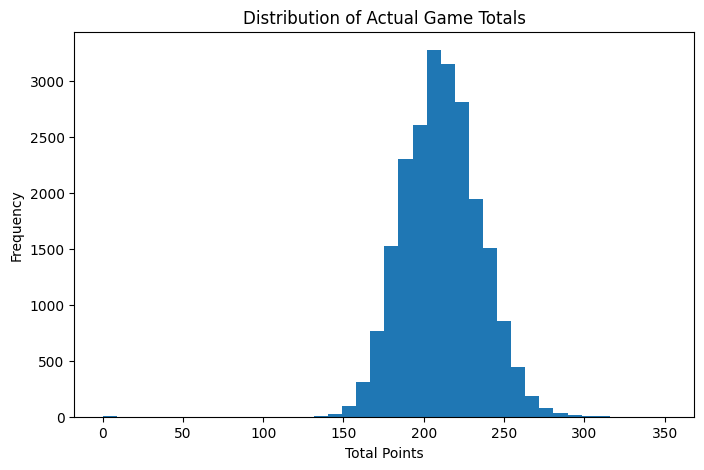

In [24]:
plt.figure(figsize=(8,5))
plt.hist(merged["actual_total"], bins=40)
plt.title("Distribution of Actual Game Totals")
plt.xlabel("Total Points")
plt.ylabel("Frequency")
plt.show()

## Baseline Linear Regression

In [25]:
y = merged["actual_total"]
X = merged[["total"]]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R²:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", root_mean_squared_error(y_test, pred))

R²: 0.41094002905680926
MAE: 13.972787491914685
RMSE: 17.797244336361874


## Polynomial Regression

In [26]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(
    merged[["total"]]
)
X_train_poly, X_test_poly, y_train, y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)

print("Polynomial Regression Results")

print("R²:", r2_score(y_test, poly_pred))
print("MAE:", mean_absolute_error(y_test, poly_pred))
print("RMSE:", root_mean_squared_error(y_test, poly_pred))

Polynomial Regression Results
R²: 0.41079165814475016
MAE: 13.978125321279352
RMSE: 17.79948555733176


In [27]:
print(poly_model.coef_)
print(poly_model.intercept_)

[0.47035891 0.0012336 ]
56.85920279927467


### Summary

Polynomial regression using a quadratic transformation of the sportsbook total produced nearly identical performance to the baseline linear regression. The R², MAE, and RMSE changed only marginally, suggesting that the relationship between the sportsbook total and the actual game total is already approximately linear. This indicates that improving predictive performance will likely require incorporating additional explanatory variables rather than simply modeling nonlinear transformations of the sportsbook total.

## Interaction Terms
Does the effect of the betting total depend on the spread?

In [28]:
interaction_df = merged[
    ["actual_total", "total", "spread"]
].dropna()

In [29]:
X = interaction_df[["total", "spread"]]
y = interaction_df["actual_total"]

interaction = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

X_interaction = interaction.fit_transform(X)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_interaction,
    y,
    test_size=0.2,
    random_state=42
)
interaction_model = LinearRegression()

interaction_model.fit(X_train_i, y_train_i)

interaction_pred = interaction_model.predict(X_test_i)

print("Interaction Model")

print("R²:", r2_score(y_test_i, interaction_pred))
print("MAE:", mean_absolute_error(y_test_i, interaction_pred))
print("RMSE:", root_mean_squared_error(y_test_i, interaction_pred))

Interaction Model
R²: 0.4295078272010493
MAE: 13.856262325955127
RMSE: 17.64511363458652


## Comparison of all Models

In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Polynomial",
        "Interaction"
    ],
    "R²": [
        r2_score(y_test, pred),
        r2_score(y_test, poly_pred),
        r2_score(y_test_i, interaction_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, pred),
        mean_absolute_error(y_test, poly_pred),
        mean_absolute_error(y_test_i, interaction_pred)
    ],
    "RMSE": [
        root_mean_squared_error(y_test, pred),
        root_mean_squared_error(y_test, poly_pred),
        root_mean_squared_error(y_test_i, interaction_pred)
    ]
})

comparison

,Model,R²,MAE,RMSE
0,Baseline,0.410940,13.972787,17.797244
1,Polynomial,0.410792,13.978125,17.799486
2,Interaction,0.429508,13.856262,17.645114


### Summary

Three linear regression models were evaluated to predict the actual total points scored in NBA games.

The baseline model used only the sportsbook total as a predictor. Adding a quadratic (polynomial) term produced almost identical performance, indicating that the relationship between the sportsbook total and the actual total is already approximately linear.

However, introducing an interaction between the sportsbook total and the point spread improved all evaluation metrics. The interaction model achieved the highest R² and the lowest MAE and RMSE, suggesting that incorporating both betting variables provides additional predictive information beyond the sportsbook total alone.

In [31]:
merged.columns

Index(['gameId', 'gameDateTimeEst', 'hometeamCity', 'hometeamName',
       'hometeamId', 'awayteamCity', 'awayteamName', 'awayteamId', 'homeScore',
       'awayScore', 'winner', 'gameType', 'gameSubtype', 'gameLabel',
       'gameSubLabel', 'seriesGameNumber', 'attendance', 'arenaId',
       'arenaName', 'arenaCity', 'arenaState', 'officials', 'gameDate',
       'season', 'date', 'regular', 'playoffs', 'away', 'home', 'score_away',
       'score_home', 'q1_away', 'q2_away', 'q3_away', 'q4_away', 'ot_away',
       'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home', 'whos_favored',
       'spread', 'total', 'moneyline_away', 'moneyline_home', 'h2_spread',
       'h2_total', 'id_spread', 'id_total', 'home_name', 'away_name',
       'actual_total', 'betting_error'],
      dtype='object')

## Categorical Analysis

To demonstrate the use of categorical predictors in linear regression, the home team is included as a categorical variable. One-hot encoding is used to convert team names into numeric dummy variables that can be used by the regression model.

In [32]:
model_df = merged[
    ["actual_total", "total", "spread", "home_name"]
].dropna()

In [33]:
model_df = pd.get_dummies(
    model_df,
    columns=["home_name"],
    drop_first=True
)

In [34]:
X = model_df.drop(columns="actual_total")
y = model_df["actual_total"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
cat_model = LinearRegression()
cat_model.fit(X_train, y_train)

pred = cat_model.predict(X_test)

print("Categorical Model")

print("R²:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", root_mean_squared_error(y_test, pred))

Categorical Model
R²: 0.4277138053442622
MAE: 13.878813784029397
RMSE: 17.672836076033136


### Interpretation

Including the home team as a categorical predictor produced performance similar to the interaction model. This suggests that team identity provides some additional information beyond the sportsbook total and spread, although the improvement remains modest.

## Correlation Matrix

In [36]:
corr = merged[
    [
        "spread",
        "total",
        "moneyline_home",
        "moneyline_away"
    ]
].corr()

corr

,spread,total,moneyline_home,moneyline_away
spread,1.000000,0.052064,-0.574863,0.437027
total,0.052064,1.000000,0.005762,-0.039877
moneyline_home,-0.574863,0.005762,1.000000,-0.832770
moneyline_away,0.437027,-0.039877,-0.832770,1.000000


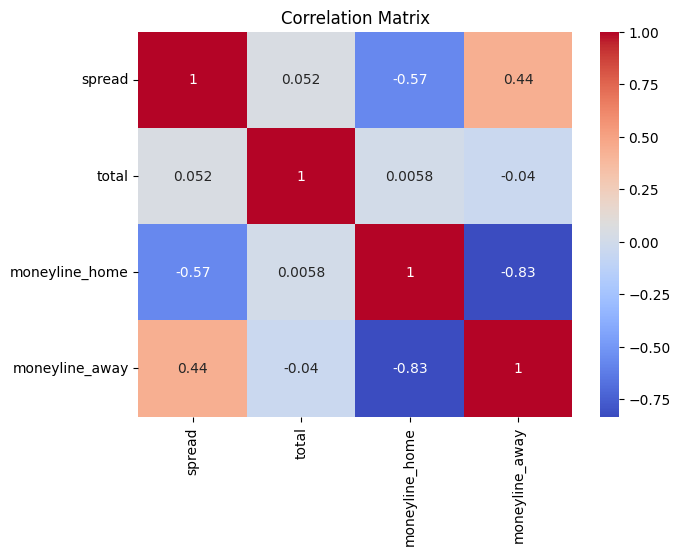

In [37]:
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Variance Inflation Factor (VIF)

In [38]:
vif_df = merged[
    [
        "spread",
        "total",
        "moneyline_home",
        "moneyline_away"
    ]
].dropna()

In [39]:
vif = pd.DataFrame()

vif["Feature"] = vif_df.columns

vif["VIF"] = [
    variance_inflation_factor(vif_df.values, i)
    for i in range(vif_df.shape[1])
]

vif

,Feature,VIF
0,spread,5.757042
1,total,4.363108
2,moneyline_home,4.511315
3,moneyline_away,3.554226


The variance inflation factor (VIF) was calculated to evaluate multicollinearity among the sportsbook betting variables. The highest VIF was observed for the point spread (5.76), indicating moderate multicollinearity. This is expected because betting variables such as the spread, game total, and moneylines are all derived from the same sportsbook pricing process. None of the variables exceeded a VIF of 10, suggesting that multicollinearity is present but not severe enough to prevent the use of linear regression.